In [1]:
!git clone https://github.com/Alexander-ha/regressors_tests_TESISFORK.git

Cloning into 'regressors_tests_TESISFORK'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 165 (delta 60), reused 122 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (165/165), 15.68 MiB | 31.13 MiB/s, done.
Resolving deltas: 100% (60/60), done.


In [4]:
import sys
sys.path.append("/content/regressors_tests_TESISFORK")

In [5]:
sys.path.append("/content/regressors_tests_TESISFORK/bin")

In [6]:
!pip install pyDOE3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00


In [25]:
# Импортируем нужные библиотеки
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # класс разбиения на данные для обучения и для проверки
from sklearn.preprocessing import MinMaxScaler
# импортируем функции
from functions import plot_true_vs_predicted,  Functions, Generate_natural_data, Generate_coded_data

In [26]:
# Исходные данные
# создаем объект класса Functions
main_function = Functions()


# определяем количетсво строк для обучения
main_function.n_samples = 4

# пределы варьирования признаков
main_function.limits = (-10, 10)

# определяем вид функции
main_function.set_function(main_function.trigonometric)

# признаки переопределим с помощью ПФЭ
data_generator = Generate_coded_data(main_function,main_function.n_samples,
                               random_seed = main_function.random_seed)
data_generator.set_matrix_type("lhs")
main_function.features = data_generator.X_coded

main_function.n_samples = data_generator.n_samples

In [27]:
rng = np.random.default_rng(seed=12345)
X_pool = rng.uniform(low=-1.0, high=1.0, size=(10000, main_function.n_features))

In [28]:
class TargetFunctionSin(Functions):
  def __init__(self,main_function, main_function_name, random_seed, n_samples, n_features, features, limits, target, rng):
    super().__init__()
    self.main_function = main_function
    self.main_function_name = main_function_name
    self.random_seed  = random_seed
    self.n_samples = n_samples
    self.n_features = n_features
    self.limits = limits
    self.features = features
    self.target = target
    self.rng = rng

  @classmethod
  def from_parent(cls, parent_instance, target, rng):
    return cls(main_function=parent_instance, main_function_name=parent_instance.main_function_name, random_seed=parent_instance.random_seed, n_samples=parent_instance.n_samples, n_features=parent_instance.n_features,features=parent_instance.features,limits= parent_instance.limits, target=target, rng=rng)
  def gen_target(self):
    for i in range(self.features.shape[0]):
            x1 = self.features[i,0]
            x2 = self.features[i,1]
            x3 = self.features[i,2]
            value = self.trigonometric(x1, x2, x3)
            self.target.append(value)

    self.target = np.array(self.target)
    return self.target
  def function(self, x1, x2, x3):
    return self.trigonometric(x1, x2, x3)

In [29]:
main_function = TargetFunctionSin.from_parent(main_function, [], rng)

In [30]:
main_function.gen_target()

array([ 0.21091617, -0.03252398, -0.09270732, -0.11170652])

In [31]:
from sklearn.datasets import load_iris
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF


In [43]:
from scipy import stats
from sklearn.gaussian_process import GaussianProcessRegressor
n_active_iterations = 20
history = []
history_scores=[]
entropy=[]
n_models = 3
n_points_to_add = 5

In [44]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern

for iteration in range(n_active_iterations):
    print(f"iter:{iteration + 1}")
    predictions = []
    scores=[]
    entropies=[]
    for i in range(n_models):
        kernel = 1.0 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.01)
        print(f"learning model number:{i}")
        model = GaussianProcessRegressor(kernel=kernel,random_state=i+228)
        model.fit(np.array(main_function.features), np.array(main_function.target))
        scores.append(model.score(main_function.features, main_function.target))
        pred, covmat = model.predict(X_pool, return_cov=True)
        sign, logdet = np.linalg.slogdet(2*np.pi*np.e*covmat)
        joint_entropy = 0.5*logdet
        variances = np.diag(covmat)
        variances = np.maximum(variances, 1e-10)
        margentro = 0.5*np.log(2*np.pi*np.e*variances)
        totalentro = np.sum(margentro)
        entropies.append(margentro)
        predictions.append(pred)
    predictions = np.array(predictions)
    entropies = np.array(entropies)
    uncertainty = predictions.std(axis=0)
    pred_entropies = np.mean(entropies, axis=0)
    #uncertainty_index = np.argsort(pred_entropies)[::-1]
    uncertainty_index = np.argsort(pred_entropies)[::-1][:n_points_to_add]
    entropy.append(np.mean(margentro))
    history_scores.append(np.mean(scores))
    for idx in uncertainty_index:
        features_to_add = X_pool[idx:idx+1]
        target_to_add = main_function.trigonometric(features_to_add[0,0], features_to_add[0,1], features_to_add[0,2])
        history.append({'iter': iteration,'features': features_to_add,'target': target_to_add, 'score': np.mean(scores), 'total entropy': np.mean(pred_entropies)})
        main_function.features = np.vstack([main_function.features, features_to_add])
        main_function.target = np.append(main_function.target, target_to_add)

    X_pool = np.delete(X_pool, uncertainty_index, axis=0)
    print("Added point")
    print(features_to_add[0])
    print("entropy")
    print(pred_entropies[uncertainty_index])
    temp_model = GaussianProcessRegressor(kernel=1.0 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.01), random_state=42)
    temp_model.fit(main_function.features, main_function.target)
    y_pred_temp = temp_model.predict(X_test)
    rmse_current = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    r2_current = r2_score(y_test, y_pred_temp)
    print(f"rmse on test: {rmse_current:.4f}")
    print(f"r2 on test: {r2_current:.4f}")



iter:1
learning model number:0
learning model number:1
learning model number:2
Added point
[-0.91889084  0.00233754 -0.99001731]
entropy
[0.37231555 0.36926775 0.36862537 0.36674488 0.36104382]
rmse on test: 0.4518
r2 on test: -0.7819
iter:2
learning model number:0


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


learning model number:1


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


learning model number:2


...

learning model number:1


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


learning model number:2


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


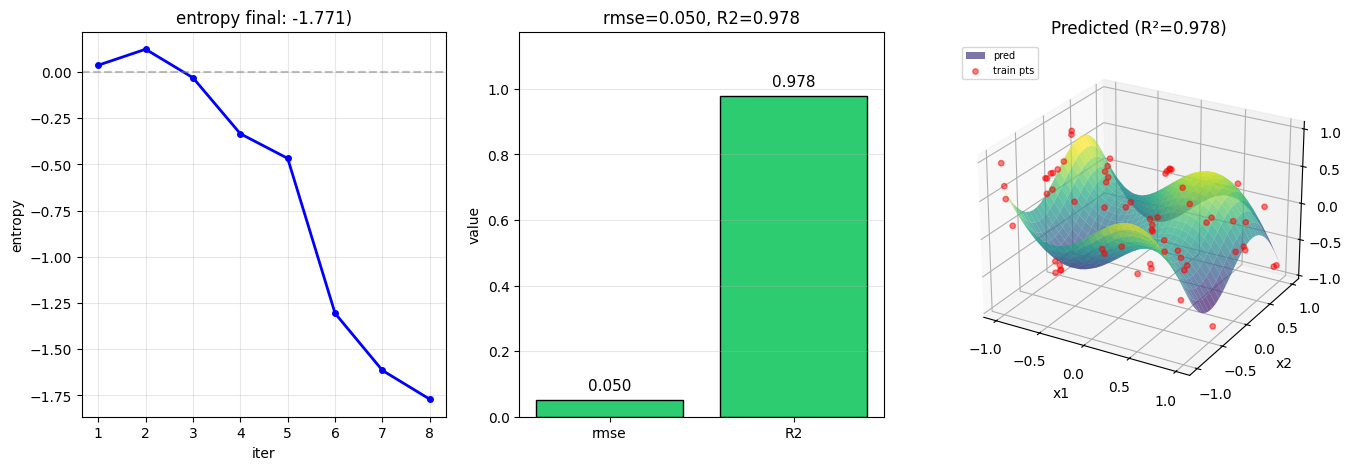

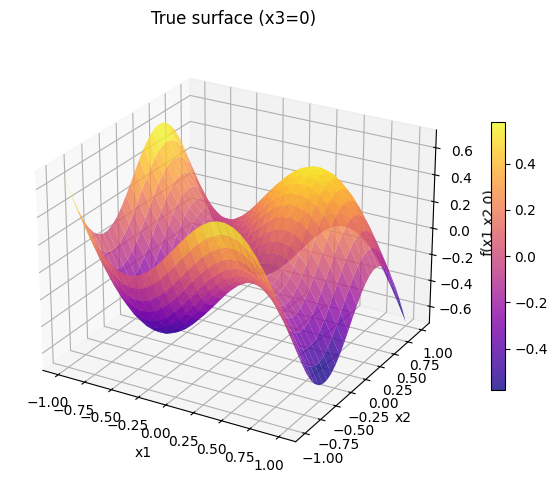

resul
samples:: 65
rmse: 0.0497
R2: 0.9785
 entropy: -1.7707


In [45]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
def create_test_grid(n_points=1000):
    rng_test = np.random.default_rng(seed=999)
    X_test = rng_test.uniform(low=-1.0, high=1.0, size=(n_points, 3))
    y_test = np.array([main_function.trigonometric(x[0], x[1], x[2]) for x in X_test])
    return X_test, y_test

X_test, y_test = create_test_grid(2000)
final_model = GaussianProcessRegressor(kernel=1.0 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.01), random_state=42)
final_model.fit(main_function.features, main_function.target)
y_pred = final_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
x1_3d = np.linspace(-1, 1, 30)
x2_3d = np.linspace(-1, 1, 30)
X1_3d, X2_3d = np.meshgrid(x1_3d, x2_3d)
Z_true = np.array([[main_function.trigonometric(x1, x2, 0) for x1, x2 in zip(row_x1, row_x2)]
                   for row_x1, row_x2 in zip(X1_3d, X2_3d)])
Z_pred = np.array([[final_model.predict([[x1, x2, 0]])[0] for x1, x2 in zip(row_x1, row_x2)]
                   for row_x1, row_x2 in zip(X1_3d, X2_3d)])

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131)
ax1.plot(range(1, len(entropy)+1), entropy, 'b-o', linewidth=2, markersize=4)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('iter')
ax1.set_ylabel('entropy')
ax1.set_title(f'entropy final: {entropy[-1]:.3f})')
ax1.grid(True, alpha=0.3)
ax2 = fig.add_subplot(132)
metrics = ['rmse', 'R2']
values = [rmse, r2]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in values]
bars = ax2.bar(metrics, values, color=colors, edgecolor='black', linewidth=1)
ax2.set_ylabel('value')
ax2.set_title(f'rmse={rmse:.3f}, R2={r2:.3f}')
ax2.set_ylim(0, max(1.0, max(values) * 1.2))
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(133, projection='3d')
surf_pred = ax3.plot_surface(X1_3d, X2_3d, Z_pred, cmap='viridis', alpha=0.7, label='pred')
ax3.scatter(main_function.features[:, 0], main_function.features[:, 1],
            main_function.target, c='red', s=15, alpha=0.5, label='train pts')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_zlabel('f')
ax3.set_title(f'Predicted (R²={r2:.3f})')
ax3.legend(loc='upper left', fontsize=7)
ax3.view_init(elev=25, azim=-60)
fig_true = plt.figure(figsize=(7, 5))
ax_true = fig_true.add_subplot(111, projection='3d')
surf_true = ax_true.plot_surface(X1_3d, X2_3d, Z_true, cmap='plasma', alpha=0.8)
ax_true.set_xlabel('x1')
ax_true.set_ylabel('x2')
ax_true.set_zlabel('f(x1,x2,0)')
ax_true.set_title('True surface (x3=0)')
ax_true.view_init(elev=25, azim=-60)
plt.colorbar(surf_true, ax=ax_true, shrink=0.6)
plt.tight_layout()
plt.savefig('true_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print("resul")
print(f"samples:: {len(main_function.target)}")
print(f"rmse: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f" entropy: {entropy[-1]:.4f}")
